In [52]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [53]:
df = pd.read_csv("Student Depression Dataset.csv")
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [54]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [55]:
encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    encoders[col] = encoder

C:\Users\Muslim\AppData\Local\Temp\ipykernel_13664\2178622537.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


In [56]:
if "id" in df.columns:
    X = df.drop(columns=["Depression", "id"])
else:
    X = df.drop(columns=["Depression"])

y = df["Depression"]

print(X.columns)

Index(['Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness'],
      dtype='str')


In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
# Logistic Regression Model

lr_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    class_weight="balanced"
)

# Train Model
lr_model.fit(X_train, y_train)

# Prediction
lr_pred = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("===== Logistic Regression =====")
print("Accuracy:", lr_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

lr_cm = confusion_matrix(y_test, lr_pred)

print("\nConfusion Matrix:")
print(lr_cm)

===== Logistic Regression =====
Accuracy: 0.8415770609318997

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      2313
           1       0.88      0.85      0.86      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.84      0.84      5580
weighted avg       0.84      0.84      0.84      5580


Confusion Matrix:
[[1929  384]
 [ 500 2767]]


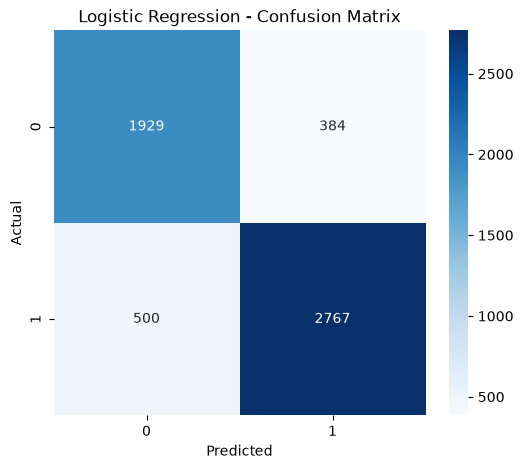

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [61]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n===== Random Forest =====")
print("Accuracy:", rf_accuracy)
print(classification_report(y_test, rf_pred))

rf_cm = confusion_matrix(y_test, rf_pred)

print("\nConfusion Matrix:")
print(rf_cm)


===== Random Forest =====
Accuracy: 0.8405017921146953
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2313
           1       0.85      0.88      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.83      5580
weighted avg       0.84      0.84      0.84      5580


Confusion Matrix:
[[1808  505]
 [ 385 2882]]


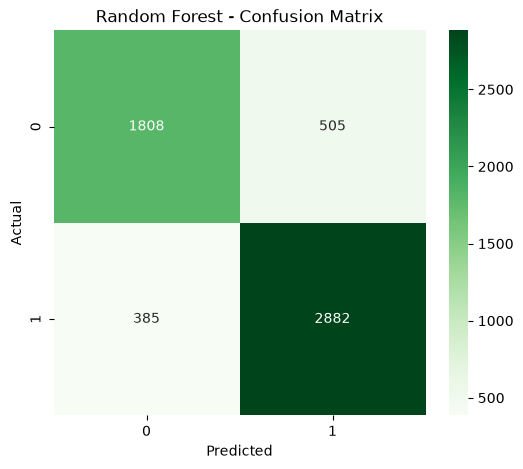

In [62]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [63]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("\n===== SVM =====")
print("Accuracy:", svm_accuracy)
print(classification_report(y_test, svm_pred))

svm_cm = confusion_matrix(y_test, svm_pred)

print("\nConfusion Matrix:")
print(lr_cm)

c:\Users\Muslim\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



===== SVM =====
Accuracy: 0.8422939068100358
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2313
           1       0.85      0.88      0.87      3267

    accuracy                           0.84      5580
   macro avg       0.84      0.83      0.84      5580
weighted avg       0.84      0.84      0.84      5580


Confusion Matrix:
[[1929  384]
 [ 500 2767]]


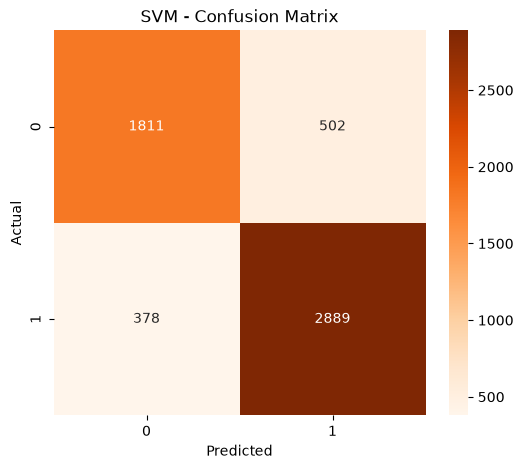

In [64]:
plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [65]:
best_model = lr_model
best_accuracy = lr_accuracy

if rf_accuracy > best_accuracy:
    best_accuracy = rf_accuracy
    best_model = rf_model

if svm_accuracy > best_accuracy:
    best_accuracy = svm_accuracy
    best_model = svm_model

print("\n==============================")
print("Model Comparison")
print("==============================")
print("Logistic Regression :", lr_accuracy)
print("Random Forest       :", rf_accuracy)
print("SVM                 :", svm_accuracy)

print("\nBest Accuracy :", best_accuracy)
print("Best Model    :", type(best_model).__name__)

print("\nBest model saved successfully!")


Model Comparison
Logistic Regression : 0.8415770609318997
Random Forest       : 0.8405017921146953
SVM                 : 0.8422939068100358

Best Accuracy : 0.8422939068100358
Best Model    : SVC

Best model saved successfully!


In [66]:
import joblib

best_accuracy = lr_accuracy
best_model = lr_model

if rf_accuracy > best_accuracy:
    best_accuracy = rf_accuracy
    best_model = rf_model

if svm_accuracy > best_accuracy:
    best_accuracy = svm_accuracy
    best_model = svm_model

print("\nBest Accuracy :", best_accuracy)
print("Best Model :", type(best_model).__name__)

joblib.dump(best_model, "best_model.pkl")

print("Best model saved successfully!")


Best Accuracy : 0.8422939068100358
Best Model : SVC
Best model saved successfully!
